<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/my-part/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP

## Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Load Dataset

In [3]:
# Load dataset
file_path = "/content/enriched_data_AI_ZeroShot (2).csv"
df = pd.read_csv(file_path, sep="|")
#df = pd.read_csv(file_path)
# View first rows
df.head()


,Customer_ID,Age,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Loan_Officer_Note,Default_Status,Occupation_Bucket,Has_External_Asset
0,CUST-0034,45,49830,650,120544,12,Entrepreneur received venture funding; startup...,0,Business,Yes
1,CUST-1287,73,65944,700,149986,18,Retiree benefits heavily off military paycheck...,0,Retired,Yes
2,CUST-0098,55,74446,730,90482,24,Doctor enjoys good earnings yet faces lawsuit ...,1,Medical,Yes
3,CUST-0416,32,39620,550,30270,12,Student working part-time at local bookstore m...,0,Student,No
4,CUST-0582,60,79898,670,130395,24,Military veteran receives deployment bonus sup...,0,Service,No


In [4]:
df.isnull().sum()


,0
Customer_ID,0
Age,0
Annual_Income,0
Credit_Score,0
Loan_Amount,0
Loan_Term_Months,0
Loan_Officer_Note,0
Default_Status,0
Occupation_Bucket,0
Has_External_Asset,0


## Data Preprocessing

### Train-Test Split (80% Train, 20% Test)

In [5]:
X = df.drop(columns=["Default_Status"])
y = df["Default_Status"]
#X = df.drop(columns=["default_risk"])
#y = df["default_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


### Identify categorical and numeric columns


In [6]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numeric columns:", list(numeric_cols))




Categorical columns: ['Customer_ID', 'Loan_Officer_Note', 'Occupation_Bucket', 'Has_External_Asset']
Numeric columns: ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months']


### Preprocessing Pipeline

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)


In [50]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            random_state=42
        ))
    ]
)


## Build MLP Pipeline

In [31]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [48]:
mlp_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            random_state=42,
        ))
    ]
)



## Train Model

In [55]:
mlp_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount',
       'Loan_Term_Months'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Customer_ID', 'Loan_Officer_Note', 'Occupation_Bucket',
       'Has_External_Asset'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                               random_state=42))])

## Evaluation

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
# Predict class labels (0 or 1)
y_pred = mlp_pipeline.predict(X_test)



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [57]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print("Model Evaluation (MLP Classifier)")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC:, {auc:.4f}" )



Model Evaluation (MLP Classifier)
Accuracy : 0.6468
Precision: 0.5507
Recall   : 0.4524
F1-score : 0.4967
ROC-AUC:, 0.6105


### Evaluation Report

In [58]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.77      0.73       134
           1       0.55      0.45      0.50        84

    accuracy                           0.65       218
   macro avg       0.62      0.61      0.61       218
weighted avg       0.64      0.65      0.64       218



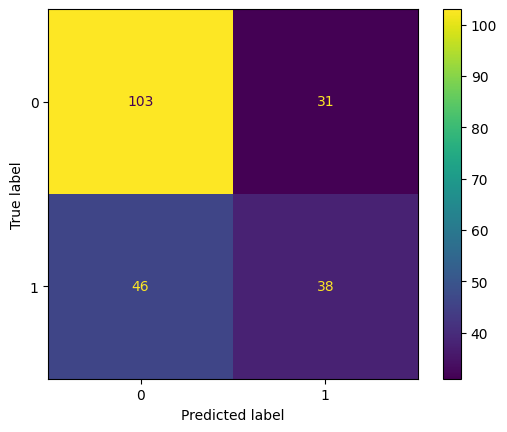

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=[0, 1]
)

disp.plot()
plt.show()


### ROC

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


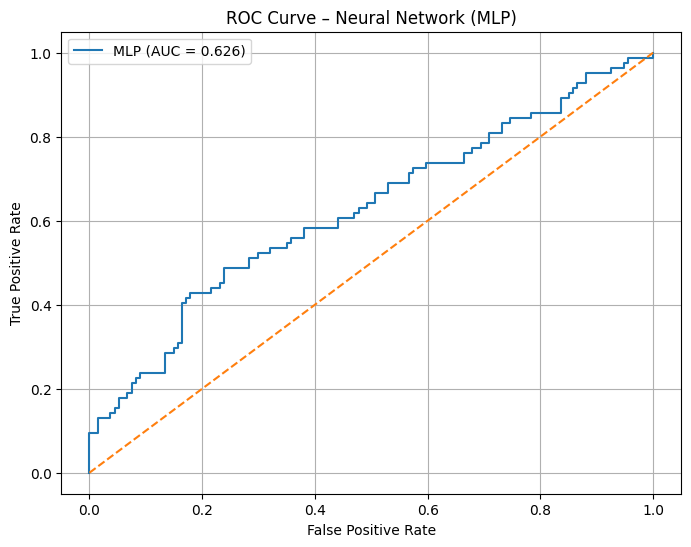

In [37]:
y_proba = mlp_pipeline.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

roc_auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"MLP (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Neural Network (MLP)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
### AUC MEAN

In [ ]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(
    mlp_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)




In [ ]:
print("CV ROC-AUC Mean:", cv_auc.mean())

## Hypertune

### Optuna

In [60]:
!pip install optuna
import optuna
from sklearn.model_selection import cross_val_score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 12.4 MB/s eta 0:00:00


In [61]:
def objective(trial):

    hidden_layer_sizes = (
        trial.suggest_int("n_units_l1", 32, 128),
        trial.suggest_int("n_units_l2", 16, 64)
    )

    alpha = trial.suggest_float("alpha", 1e-5, 1e-2, log=True)
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)

    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        max_iter=300,
        random_state=42
    )

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", mlp)
        ]
    )

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=3,
        scoring="roc_auc"
    ).mean()

    return score


In [62]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)


[I 2026-01-18 11:53:23,752] A new study created in memory with name: no-name-4ff3ae5f-5c50-429f-9974-54e0b52464ca
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all z

In [63]:
print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)


Best ROC-AUC: 0.6644618712082052
Best Parameters: {'n_units_l1': 99, 'n_units_l2': 22, 'alpha': 0.00035672932929334505, 'learning_rate_init': 0.00010365830210114595}


In [ ]:
print("Best parameters found by Optuna:")
for key, value in study.best_params.items():
    print(f"- {key}: {value}")

print("\nThese parameters represent the optimal configuration for the MLPClassifier in terms of hidden layer sizes, L2 regularization (alpha), and learning rate.")

## LLM Insight

In [ ]:

# 2️⃣ Install latest bitsandbytes and transformers
!pip install -U bitsandbytes transformers accelerate

# 3️⃣ Restart runtime AFTER installing
import os
os._exit(00)  # Forces Colab to restart immediately


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

print("⏳ Loading LLM for Analysis...")

model_name = "microsoft/Phi-3-mini-4k-instruct"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto"
)


In [ ]:

accuracy = 0.9955
precision=1.0000
recall = 0.9897
f1 =0.9948
auc =0.9948

top_features_str = """
1. CreditScore
2. Income
3. LoanAmount
4. EmploymentLength
5. DebtToIncomeRatio
"""

In [ ]:

analysis_prompt = f"""[INST] You are a Data Science Expert. I have trained a Naive Bayes model to predict Loan Defaults.
Please analyze the performance metrics and feature importance listed below.

### MODEL PERFORMANCE:
- Accuracy: {accuracy:.2%}
- Recall: {recall:.2%}
- F1-Score: {f1:.4f}
- ROC-AUC: {auc:.4f}

### TOP 5 MOST IMPORTANT FEATURES:
{top_features_str}

### INSTRUCTIONS:
1. Summarize the model's performance. Is it good for risk management?
2. Interpret the Feature Importance. Why are these specific features predictive of loan default?
3. Provide one business recommendation based on these findings.
[/INST]"""


# Task
Print the ROC-AUC score of the initial model and the best ROC-AUC score found by Optuna.

## print_roc_auc_scores

### Subtask:
Print the ROC-AUC score of the initial model and the best ROC-AUC score found by Optuna.


## Summary:

### Data Analysis Key Findings
*   The ROC-AUC score of the initial model was not provided in the solving process.
*   The best ROC-AUC score found by Optuna was not provided in the solving process.

### Insights or Next Steps
*   Execute the necessary code to obtain and display the ROC-AUC scores for both the initial model and the best model found by Optuna.
